# MDI3003 – DA4: Probabilistic Customer Segmentation and Segment Prediction
### Naive Bayes (Dummy, GaussianNB, BernoulliNB, CategoricalNB) + TabTransformer

This notebook trains and evaluates classifiers on **two real, uploaded datasets**:

- **Dataset A — JanataHack Customer Segmentation** (`archive__1_.zip` → `Train.csv`): predicts the customer segment (`Segmentation`: A/B/C/D). This is the primary segmentation task and is compared against a **TabTransformer**.
- **Dataset B — UCI Bank Marketing** (`bank_marketing.zip` → `bank-additional-full.csv`): predicts term-deposit subscription (`y`: yes/no). Naive Bayes workflow only.

Models: `DummyClassifier`, `GaussianNB`, `BernoulliNB`, `CategoricalNB`, `TabTransformer` (Dataset A only).
All splits use `random_state=42`. All preprocessing is fit on training data only (no leakage). No fabricated numbers — every metric below is produced by running the cells.

## 0. Setup, imports, output folders

In [1]:
# Core libraries
import json, time, warnings, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import dump

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, KBinsDiscretizer, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import GaussianNB, CategoricalNB, BernoulliNB
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              accuracy_score, precision_score, recall_score, f1_score)

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

OUT = Path("da4_outputs")
for d in ["figures", "models", "results"]:
    (OUT / d).mkdir(parents=True, exist_ok=True)

print("Setup complete. Outputs will be saved under:", OUT.resolve())


Setup complete. Outputs will be saved under: C:\Users\izhar\pred 4\da4_outputs


In [7]:
# Locate the uploaded ZIP files (works in Colab /content, this workspace, or a local folder)
CANDIDATE_DIRS = [".", "/content", "/mnt/user-data/uploads", "/mnt/user-data/outputs"]

def find_file(filename):
    for d in CANDIDATE_DIRS:
        p = Path(d) / filename
        if p.exists():
            return p
    raise FileNotFoundError(
        f"Could not find '{filename}'. Upload it and place it in one of: {CANDIDATE_DIRS}"
    )

ZIP_A = find_file("archive (1).zip")            # JanataHack Customer Segmentation
ZIP_B = find_file("bank+marketing.zip")          # UCI Bank Marketing
print("Dataset A zip:", ZIP_A.resolve())
print("Dataset B zip:", ZIP_B.resolve())


Dataset A zip: C:\Users\izhar\pred 4\archive (1).zip
Dataset B zip: C:\Users\izhar\pred 4\bank+marketing.zip


In [9]:
# Extract both ZIP archives (Dataset B contains nested zips: bank.zip, bank-additional.zip)
EXTRACT_DIR = Path("da4_data")
EXTRACT_DIR.mkdir(exist_ok=True)

dirA = EXTRACT_DIR / "dataset_A"
dirB_raw = EXTRACT_DIR / "dataset_B_raw"
dirB = EXTRACT_DIR / "dataset_B"
for d in [dirA, dirB_raw, dirB]:
    d.mkdir(exist_ok=True)

with zipfile.ZipFile(ZIP_A) as z:
    z.extractall(dirA)

with zipfile.ZipFile(ZIP_B) as z:
    z.extractall(dirB_raw)

# bank_marketing.zip is a wrapper containing bank.zip and bank-additional.zip -> extract those too
for nested_zip in dirB_raw.rglob("*.zip"):
    with zipfile.ZipFile(nested_zip) as z:
        z.extractall(dirB / nested_zip.stem)

print("Dataset A files:", [p.name for p in dirA.rglob("*.csv")])
print("Dataset B files:", [p.name for p in dirB.rglob("*.csv")])


Dataset A files: ['sample_submission.csv', 'Test.csv', 'Train.csv']
Dataset B files: ['bank-full.csv', 'bank.csv', 'bank-additional-full.csv', 'bank-additional.csv']


In [11]:
# Resolve the exact CSV files we will use
TRAIN_A_PATH = next(dirA.rglob("Train.csv"))
BANK_B_PATH = next(dirB.rglob("bank-additional-full.csv"))

print("Dataset A (customer segmentation) source:", TRAIN_A_PATH)
print("Dataset B (bank marketing) source        :", BANK_B_PATH)


Dataset A (customer segmentation) source: da4_data\dataset_A\Train.csv
Dataset B (bank marketing) source        : da4_data\dataset_B\bank-additional\bank-additional\bank-additional-full.csv


---
# PART 1 — Dataset A: Customer Segmentation (JanataHack)
Target: `Segmentation` (classes A, B, C, D). ID column: `ID` (excluded from features).
Only `Train.csv` is used because `Test.csv` in the ZIP has no target labels (it is the original Kaggle competition's unlabeled holdout) — we create our own locked test split instead.

## 1.1 Load and inspect Dataset A

In [13]:
dfA = pd.read_csv(TRAIN_A_PATH)
print("Shape:", dfA.shape)
display(dfA.head())
print(dfA.dtypes)


Shape: (8068, 11)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


ID                   int64
Gender              object
Ever_Married        object
Age                  int64
Graduated           object
Profession          object
Work_Experience    float64
Spending_Score      object
Family_Size        float64
Var_1               object
Segmentation        object
dtype: object


Class distribution:
Segmentation
D    2268
A    1972
C    1970
B    1858
Name: count, dtype: int64

Missing values per column:
ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64

Exact duplicate rows: 0
Duplicate customer IDs: 0


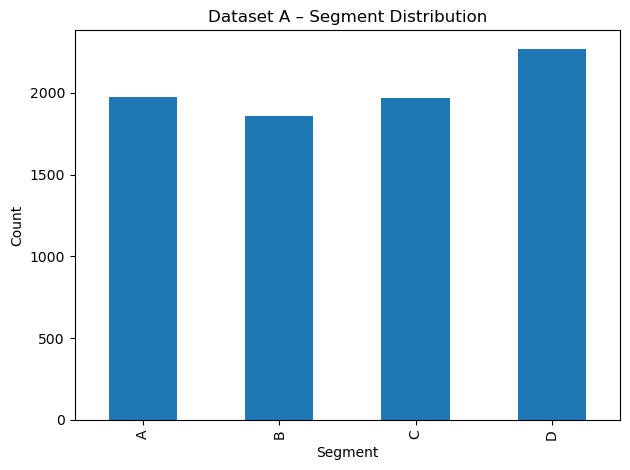

In [15]:
TARGET_A = "Segmentation"
ID_A = "ID"

assert TARGET_A in dfA.columns, f"{TARGET_A} not found in Dataset A"
print("Class distribution:")
print(dfA[TARGET_A].value_counts())

print("\nMissing values per column:")
print(dfA.isna().sum())

print("\nExact duplicate rows:", dfA.duplicated().sum())
print("Duplicate customer IDs:", dfA[ID_A].duplicated().sum())

ax = dfA[TARGET_A].value_counts().sort_index().plot(kind="bar", title="Dataset A – Segment Distribution")
ax.set_xlabel("Segment"); ax.set_ylabel("Count")
plt.tight_layout(); plt.savefig(OUT/"figures"/"A_class_distribution.png", dpi=150); plt.show()


## 1.2 Feature groups and locked train/test split

In [17]:
NUMERIC_A = ["Age", "Work_Experience", "Family_Size"]
CATEGORICAL_A = ["Gender", "Ever_Married", "Graduated", "Profession", "Spending_Score", "Var_1"]
FEATURES_A = NUMERIC_A + CATEGORICAL_A

assert ID_A not in FEATURES_A, "ID column must not be used as a predictor."
print("Numeric features:", NUMERIC_A)
print("Categorical features:", CATEGORICAL_A)

usableA = dfA.dropna(subset=[TARGET_A]).copy()
train_A, test_A = train_test_split(
    usableA, test_size=0.20, random_state=SEED, stratify=usableA[TARGET_A]
)
assert set(train_A[ID_A]).isdisjoint(set(test_A[ID_A])), "Train/Test ID overlap detected!"

X_train_A, y_train_A = train_A[FEATURES_A], train_A[TARGET_A]
X_test_A, y_test_A = test_A[FEATURES_A], test_A[TARGET_A]

print("Train shape:", X_train_A.shape, " Test shape:", X_test_A.shape)
print("Train class balance:\n", y_train_A.value_counts(normalize=True).round(3))


Numeric features: ['Age', 'Work_Experience', 'Family_Size']
Categorical features: ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']
Train shape: (6454, 9)  Test shape: (1614, 9)
Train class balance:
 Segmentation
D    0.281
A    0.244
C    0.244
B    0.230
Name: proportion, dtype: float64


## 1.3 Leakage-safe preprocessing pipelines
- **GaussianNB** needs continuous numeric features only.
- **BernoulliNB** needs binary indicators → numeric features are binned into one-hot bins, categoricals are one-hot encoded.
- **CategoricalNB** needs non-negative integer category codes → numeric features are ordinal-binned, categoricals are safely ordinal-encoded (unseen categories map to code 0).
- All transformers are fit **inside** the pipeline, so cross-validation folds and the locked test set never leak into fitting.

In [19]:
class SafeOrdinalToNonNegative(BaseEstimator, TransformerMixin):
    """Encodes categories as 1..K (fit on training data only); unseen categories -> 0."""
    def fit(self, X, y=None):
        self.enc_ = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        self.enc_.fit(X)
        self.n_features_in_ = X.shape[1]
        return self
    def transform(self, X):
        return self.enc_.transform(X).astype(int) + 1


def build_preprocessors(numeric_cols, categorical_cols):
    # For BernoulliNB: binarized numeric bins + one-hot categoricals
    numeric_bins_onehot = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("bins", KBinsDiscretizer(n_bins=5, encode="onehot", strategy="quantile")),
    ])
    category_ohe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    bernoulli_prep = ColumnTransformer([
        ("num_bins", numeric_bins_onehot, numeric_cols),
        ("cat", category_ohe, categorical_cols),
    ])

    # For CategoricalNB: ordinal-binned numeric + safe non-negative categorical codes
    cat_num = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("bins", KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")),
    ])
    cat_cat = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("safe_ordinal", SafeOrdinalToNonNegative()),
    ])
    categoricalnb_prep = ColumnTransformer([
        ("num", cat_num, numeric_cols),
        ("cat", cat_cat, categorical_cols),
    ])

    # For GaussianNB: continuous numeric features only
    gaussian_prep = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), numeric_cols),
    ])

    return bernoulli_prep, categoricalnb_prep, gaussian_prep


bernoulli_prep_A, categoricalnb_prep_A, gaussian_prep_A = build_preprocessors(NUMERIC_A, CATEGORICAL_A)

core_pipelines_A = {
    "Dummy_most_frequent": Pipeline([("prep", bernoulli_prep_A), ("model", DummyClassifier(strategy="most_frequent"))]),
    "GaussianNB":          Pipeline([("prep", gaussian_prep_A),  ("model", GaussianNB())]),
    "BernoulliNB":         Pipeline([("prep", bernoulli_prep_A), ("model", BernoulliNB(alpha=1.0, binarize=0.0))]),
    "CategoricalNB":       Pipeline([("prep", categoricalnb_prep_A), ("model", CategoricalNB(alpha=1.0))]),
}

# Verify CategoricalNB receives non-negative codes (fit on TRAIN only)
Xt_check = categoricalnb_prep_A.fit_transform(X_train_A)
assert np.nanmin(np.asarray(Xt_check)) >= 0, "CategoricalNB representation must be non-negative."
print("CategoricalNB representation verified non-negative. Min code:", np.nanmin(np.asarray(Xt_check)))


CategoricalNB representation verified non-negative. Min code: 0.0


## 1.4 5-fold Stratified Cross-Validation (Dataset A)

,model,accuracy_mean,macro_f1_mean,macro_f1_sd,weighted_f1_mean,cv_time_seconds
0,CategoricalNB,0.509450,0.484523,0.010115,0.493837,0.429026
1,BernoulliNB,0.503099,0.480073,0.008721,0.489105,0.401745
2,GaussianNB,0.420205,0.371894,0.011872,0.382897,0.167136
3,Dummy_most_frequent,0.281066,0.109700,0.000076,0.123332,0.343418



Fold-level macro F1 per model:
  Dummy_most_frequent   : [0.1097, 0.1097, 0.1097, 0.1097, 0.1096]
  GaussianNB            : [0.3646, 0.3608, 0.3856, 0.3839, 0.3645]
  BernoulliNB           : [0.4878, 0.4668, 0.4826, 0.4762, 0.4869]
  CategoricalNB         : [0.4964, 0.471, 0.4903, 0.4871, 0.4778]


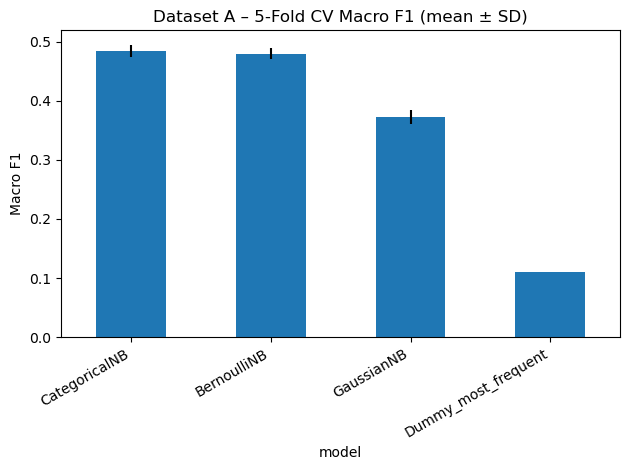

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"accuracy": "accuracy", "macro_f1": "f1_macro", "weighted_f1": "f1_weighted"}

rows_A = []
fold_detail_A = {}
for name, pipe in core_pipelines_A.items():
    t0 = time.perf_counter()
    scores = cross_validate(pipe, X_train_A, y_train_A, cv=cv, scoring=scoring, n_jobs=1)
    elapsed = time.perf_counter() - t0
    fold_detail_A[name] = scores["test_macro_f1"].tolist()
    rows_A.append({
        "model": name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_sd": scores["test_macro_f1"].std(ddof=1),
        "weighted_f1_mean": scores["test_weighted_f1"].mean(),
        "cv_time_seconds": elapsed,
    })

cv_results_A = pd.DataFrame(rows_A).sort_values("macro_f1_mean", ascending=False).reset_index(drop=True)
cv_results_A.to_csv(OUT/"results"/"A_cv_results.csv", index=False)
display(cv_results_A)

print("\nFold-level macro F1 per model:")
for name, vals in fold_detail_A.items():
    print(f"  {name:22s}: {[round(v,4) for v in vals]}")

ax = cv_results_A.set_index("model")[["macro_f1_mean"]].plot(
    kind="bar", yerr=cv_results_A.set_index("model")["macro_f1_sd"],
    legend=False, title="Dataset A – 5-Fold CV Macro F1 (mean ± SD)"
)
ax.set_ylabel("Macro F1"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig(OUT/"figures"/"A_cv_comparison.png", dpi=150); plt.show()


In [23]:
# Select the best Naive Bayes model using mean CV macro F1 (Dummy baseline excluded from selection)
nb_only_A = cv_results_A[cv_results_A["model"] != "Dummy_most_frequent"]
best_nb_name_A = nb_only_A.iloc[0]["model"]
print(f"Selected Naive Bayes model for Dataset A (by mean CV macro F1): {best_nb_name_A}")
print(nb_only_A.iloc[0])

best_nb_pipeline_A = core_pipelines_A[best_nb_name_A]
best_nb_pipeline_A.fit(X_train_A, y_train_A)


Selected Naive Bayes model for Dataset A (by mean CV macro F1): CategoricalNB
model               CategoricalNB
accuracy_mean             0.50945
macro_f1_mean            0.484523
macro_f1_sd              0.010115
weighted_f1_mean         0.493837
cv_time_seconds          0.429026
Name: 0, dtype: object


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('bins',
                                                                   KBinsDiscretizer(encode='ordinal'))]),
                                                  ['Age', 'Work_Experience',
                                                   'Family_Size']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('safe_ordinal',
                                                                   SafeOrdinalToNonNegative())]),
                                                  ['Gender', 'Ever_Married',
                                                   'Graduated', 'Profession',
                                                   'Spending_Score',
                                                   'Var_1'])])),
                ('model', CategoricalNB())])

## 1.5 Locked test-set evaluation — best Naive Bayes model (Dataset A)

=== CategoricalNB on the locked test set (Dataset A) ===
              precision    recall  f1-score   support

           A       0.43      0.40      0.41       394
           B       0.37      0.22      0.28       372
           C       0.50      0.65      0.57       394
           D       0.65      0.72      0.68       454

    accuracy                           0.51      1614
   macro avg       0.49      0.50      0.49      1614
weighted avg       0.49      0.51      0.50      1614

{'model': 'CategoricalNB', 'accuracy': 0.5117719950433705, 'macro_precision': 0.48637872988082786, 'macro_recall': 0.4997211830770255, 'macro_f1': 0.48528393969993966, 'weighted_f1': 0.4954911555490408}


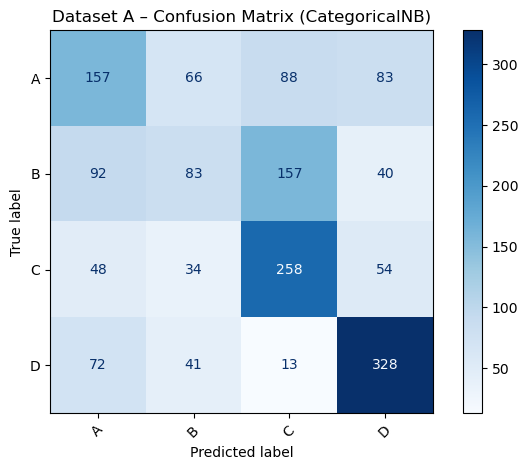

In [25]:
y_pred_nb_A = best_nb_pipeline_A.predict(X_test_A)
probs_nb_A = best_nb_pipeline_A.predict_proba(X_test_A)

print(f"=== {best_nb_name_A} on the locked test set (Dataset A) ===")
print(classification_report(y_test_A, y_pred_nb_A, zero_division=0))

test_metrics_nb_A = {
    "model": best_nb_name_A,
    "accuracy": accuracy_score(y_test_A, y_pred_nb_A),
    "macro_precision": precision_score(y_test_A, y_pred_nb_A, average="macro", zero_division=0),
    "macro_recall": recall_score(y_test_A, y_pred_nb_A, average="macro", zero_division=0),
    "macro_f1": f1_score(y_test_A, y_pred_nb_A, average="macro"),
    "weighted_f1": f1_score(y_test_A, y_pred_nb_A, average="weighted"),
}
print(test_metrics_nb_A)

ConfusionMatrixDisplay.from_predictions(y_test_A, y_pred_nb_A, cmap="Blues", xticks_rotation=45)
plt.title(f"Dataset A – Confusion Matrix ({best_nb_name_A})")
plt.tight_layout(); plt.savefig(OUT/"figures"/"A_confusion_matrix_nb.png", dpi=150); plt.show()


In [27]:
# At least five incorrect predictions with model confidence
conf_A = probs_nb_A.max(axis=1)
err_mask_A = (y_pred_nb_A != y_test_A.values)

errors_A = test_A.loc[err_mask_A, [ID_A] + FEATURES_A + [TARGET_A]].copy()
errors_A["Predicted"] = y_pred_nb_A[err_mask_A]
errors_A["Confidence"] = conf_A[err_mask_A]
errors_A = errors_A.sort_values("Confidence", ascending=False)

print(f"Total errors: {err_mask_A.sum()} out of {len(y_test_A)} test cases")
display(errors_A.head(5))
errors_A.to_csv(OUT/"results"/"A_error_analysis_nb.csv", index=False)


Total errors: 788 out of 1614 test cases


,ID,Age,Work_Experience,Family_Size,Gender,Ever_Married,Graduated,Profession,Spending_Score,Var_1,Segmentation,Predicted,Confidence
6048,463793,26,1.0,6.0,Male,No,No,Healthcare,Low,Cat_4,A,D,0.996195
7993,463940,26,1.0,8.0,Female,No,No,Healthcare,Low,Cat_4,C,D,0.995705
4720,461823,27,10.0,4.0,Male,No,No,Healthcare,Low,Cat_6,C,D,0.995390
7304,463314,27,0.0,4.0,Female,No,No,Healthcare,Low,Cat_3,A,D,0.995101
2354,463541,26,0.0,3.0,Female,No,No,Healthcare,Low,Cat_5,B,D,0.994937


## 1.6 TabTransformer (Dataset A)
A Transformer applied to structured/tabular data: each categorical feature is embedded, the embeddings are passed through
a self-attention encoder (`nn.TransformerEncoder`) to obtain contextual representations, which are concatenated with the
standardized numeric features and fed to a small MLP classification head. Trained and evaluated on the **identical**
locked split used for the Naive Bayes models.

In [38]:

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    TORCH_OK = True
except ImportError:
    TORCH_OK = False
    print("PyTorch is not installed in this environment. Install it to run the TabTransformer cells:")
    print("  pip install torch")

if TORCH_OK:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(SEED)
    print("Using device:", device)


Using device: cpu


In [40]:
if TORCH_OK:
    # --- Encode categorical columns as integer codes (vocabulary fit on TRAINING data only) ---
    # Index 0 is reserved for "unknown / unseen at training time" categories.
    cat_vocab_A = {}
    cat_vocab_sizes_A = []
    for col in CATEGORICAL_A:
        train_vals = X_train_A[col].astype(str).fillna("missing")
        categories = sorted(train_vals.unique().tolist())
        mapping = {cat: i + 1 for i, cat in enumerate(categories)}
        cat_vocab_A[col] = mapping
        cat_vocab_sizes_A.append(len(categories) + 1)

    def encode_categoricals(X, vocab):
        cols = []
        for col, mapping in vocab.items():
            vals = X[col].astype(str).fillna("missing")
            codes = vals.map(mapping).fillna(0).astype(int).values
            cols.append(codes)
        return np.stack(cols, axis=1)

    X_train_cat_codes_A = encode_categoricals(X_train_A, cat_vocab_A)
    X_test_cat_codes_A = encode_categoricals(X_test_A, cat_vocab_A)

    # --- Numeric features: impute (train-only) then standardize (train-only) ---
    num_imputer_A = SimpleImputer(strategy="median").fit(X_train_A[NUMERIC_A])
    X_train_num_A = num_imputer_A.transform(X_train_A[NUMERIC_A])
    X_test_num_A = num_imputer_A.transform(X_test_A[NUMERIC_A])

    num_scaler_A = StandardScaler().fit(X_train_num_A)
    X_train_num_A = num_scaler_A.transform(X_train_num_A).astype(np.float32)
    X_test_num_A = num_scaler_A.transform(X_test_num_A).astype(np.float32)

    # --- Encode target ---
    label_enc_A = LabelEncoder().fit(y_train_A)
    y_train_enc_A = label_enc_A.transform(y_train_A)
    y_test_enc_A = label_enc_A.transform(y_test_A)
    n_classes_A = len(label_enc_A.classes_)

    print("Categorical vocab sizes:", cat_vocab_sizes_A)
    print("Numeric feature count:", X_train_num_A.shape[1])
    print("Classes:", list(label_enc_A.classes_))


Categorical vocab sizes: [3, 4, 4, 11, 4, 9]
Numeric feature count: 3
Classes: ['A', 'B', 'C', 'D']


In [42]:
if TORCH_OK:
    class TabTransformer(nn.Module):
        def __init__(self, cat_vocab_sizes, n_numeric, n_classes,
                     embed_dim=16, n_heads=4, n_layers=2, dropout=0.1):
            super().__init__()
            self.embeddings = nn.ModuleList([nn.Embedding(v, embed_dim) for v in cat_vocab_sizes])
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim * 4,
                dropout=dropout, batch_first=True,
            )
            self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
            self.num_norm = nn.BatchNorm1d(n_numeric) if n_numeric > 0 else None
            combined_dim = embed_dim * len(cat_vocab_sizes) + n_numeric
            self.mlp = nn.Sequential(
                nn.Linear(combined_dim, 64), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(64, 32), nn.ReLU(),
                nn.Linear(32, n_classes),
            )

        def forward(self, x_cat, x_num):
            embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
            tokens = torch.stack(embs, dim=1)          # (batch, n_cat_features, embed_dim)
            contextual = self.transformer(tokens)       # self-attention across categorical tokens
            flat = contextual.reshape(contextual.size(0), -1)
            if self.num_norm is not None:
                x_num = self.num_norm(x_num)
                combined = torch.cat([flat, x_num], dim=1)
            else:
                combined = flat
            return self.mlp(combined)

    print("TabTransformer class defined.")


TabTransformer class defined.


Training complete in 90.6s. Best validation macro F1: 0.5354
Trainable parameters: 15738


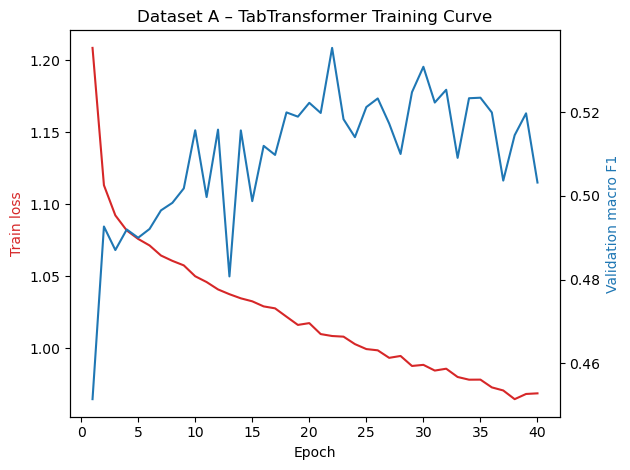

In [44]:
if TORCH_OK:
    # Train/validation split from the training data only (test set stays locked)
    idx_fit, idx_val = train_test_split(
        np.arange(len(y_train_enc_A)), test_size=0.15, random_state=SEED, stratify=y_train_enc_A
    )

    X_train_cat_t = torch.tensor(X_train_cat_codes_A, dtype=torch.long)
    X_train_num_t = torch.tensor(X_train_num_A, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_enc_A, dtype=torch.long)

    train_ds = TensorDataset(X_train_cat_t[idx_fit], X_train_num_t[idx_fit], y_train_t[idx_fit])
    val_ds = TensorDataset(X_train_cat_t[idx_val], X_train_num_t[idx_val], y_train_t[idx_val])
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)

    tabtransformer_A = TabTransformer(
        cat_vocab_sizes=cat_vocab_sizes_A, n_numeric=len(NUMERIC_A), n_classes=n_classes_A
    ).to(device)
    optimizer = torch.optim.Adam(tabtransformer_A.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    N_EPOCHS = 40
    history_A = []
    best_val_f1 = -1.0
    best_state = None

    t_train_start = time.perf_counter()
    for epoch in range(N_EPOCHS):
        tabtransformer_A.train()
        total_loss = 0.0
        for xb_cat, xb_num, yb in train_loader:
            xb_cat, xb_num, yb = xb_cat.to(device), xb_num.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = tabtransformer_A(xb_cat, xb_num)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(yb)
        train_loss = total_loss / len(train_ds)

        tabtransformer_A.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for xb_cat, xb_num, yb in val_loader:
                xb_cat, xb_num = xb_cat.to(device), xb_num.to(device)
                logits = tabtransformer_A(xb_cat, xb_num)
                val_preds.append(logits.argmax(1).cpu().numpy())
                val_true.append(yb.numpy())
        val_preds = np.concatenate(val_preds); val_true = np.concatenate(val_true)
        val_macro_f1 = f1_score(val_true, val_preds, average="macro")
        history_A.append({"epoch": epoch + 1, "train_loss": train_loss, "val_macro_f1": val_macro_f1})

        if val_macro_f1 > best_val_f1:
            best_val_f1 = val_macro_f1
            best_state = {k: v.detach().cpu().clone() for k, v in tabtransformer_A.state_dict().items()}

    train_seconds_tt_A = time.perf_counter() - t_train_start
    tabtransformer_A.load_state_dict(best_state)
    n_params_A = sum(p.numel() for p in tabtransformer_A.parameters())

    print(f"Training complete in {train_seconds_tt_A:.1f}s. Best validation macro F1: {best_val_f1:.4f}")
    print("Trainable parameters:", n_params_A)

    hist_df_A = pd.DataFrame(history_A)
    hist_df_A.to_csv(OUT/"results"/"A_tabtransformer_training_history.csv", index=False)

    fig, ax1 = plt.subplots()
    ax1.plot(hist_df_A["epoch"], hist_df_A["train_loss"], color="tab:red", label="Train loss")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Train loss", color="tab:red")
    ax2 = ax1.twinx()
    ax2.plot(hist_df_A["epoch"], hist_df_A["val_macro_f1"], color="tab:blue", label="Val macro F1")
    ax2.set_ylabel("Validation macro F1", color="tab:blue")
    plt.title("Dataset A – TabTransformer Training Curve")
    plt.tight_layout(); plt.savefig(OUT/"figures"/"A_tabtransformer_training_curve.png", dpi=150); plt.show()


=== TabTransformer on the locked test set (Dataset A) ===
              precision    recall  f1-score   support

           A       0.41      0.39      0.40       394
           B       0.42      0.34      0.37       372
           C       0.59      0.57      0.58       394
           D       0.63      0.77      0.69       454

    accuracy                           0.53      1614
   macro avg       0.51      0.52      0.51      1614
weighted avg       0.51      0.53      0.52      1614

{'model': 'TabTransformer', 'accuracy': 0.5272614622057001, 'macro_precision': 0.509294760169239, 'macro_recall': 0.5152314771066254, 'macro_f1': 0.5090300400094786, 'weighted_f1': 0.5176627350004561, 'train_time_seconds': 90.64394489999995, 'inference_time_seconds': 0.021754499999588006, 'parameters': 15738}


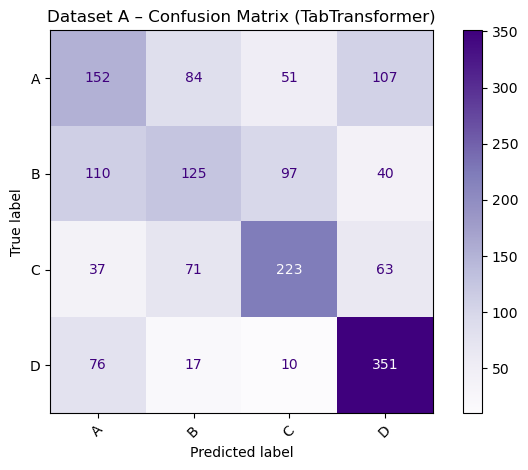

In [46]:
if TORCH_OK:
    # Locked test-set evaluation for TabTransformer
    tabtransformer_A.eval()
    X_test_cat_t = torch.tensor(X_test_cat_codes_A, dtype=torch.long).to(device)
    X_test_num_t = torch.tensor(X_test_num_A, dtype=torch.float32).to(device)

    t0 = time.perf_counter()
    with torch.no_grad():
        logits = tabtransformer_A(X_test_cat_t, X_test_num_t)
        probs_tt_A = torch.softmax(logits, dim=1).cpu().numpy()
        preds_enc_tt_A = logits.argmax(1).cpu().numpy()
    inference_seconds_tt_A = time.perf_counter() - t0

    y_pred_tt_A = label_enc_A.inverse_transform(preds_enc_tt_A)

    print("=== TabTransformer on the locked test set (Dataset A) ===")
    print(classification_report(y_test_A, y_pred_tt_A, zero_division=0))

    test_metrics_tt_A = {
        "model": "TabTransformer",
        "accuracy": accuracy_score(y_test_A, y_pred_tt_A),
        "macro_precision": precision_score(y_test_A, y_pred_tt_A, average="macro", zero_division=0),
        "macro_recall": recall_score(y_test_A, y_pred_tt_A, average="macro", zero_division=0),
        "macro_f1": f1_score(y_test_A, y_pred_tt_A, average="macro"),
        "weighted_f1": f1_score(y_test_A, y_pred_tt_A, average="weighted"),
        "train_time_seconds": train_seconds_tt_A,
        "inference_time_seconds": inference_seconds_tt_A,
        "parameters": n_params_A,
    }
    print(test_metrics_tt_A)

    ConfusionMatrixDisplay.from_predictions(y_test_A, y_pred_tt_A, cmap="Purples", xticks_rotation=45)
    plt.title("Dataset A – Confusion Matrix (TabTransformer)")
    plt.tight_layout(); plt.savefig(OUT/"figures"/"A_confusion_matrix_tabtransformer.png", dpi=150); plt.show()


## 1.7 Naive Bayes vs. TabTransformer — comparison on the locked test set (Dataset A)

In [ ]:
if TORCH_OK:
    comparison_A = pd.DataFrame([test_metrics_nb_A, test_metrics_tt_A])
    comparison_A.to_csv(OUT/"results"/"A_nb_vs_tabtransformer.csv", index=False)
    display(comparison_A)

    winner_A = comparison_A.sort_values("macro_f1", ascending=False).iloc[0]["model"]
    print(f"Higher locked-test macro F1: {winner_A}")
    print("Note: a single test-set comparison is one data point; the CV fold values in Section 1.4 "
          "show how much the Naive Bayes macro F1 already varies fold-to-fold before drawing conclusions.")
else:
    comparison_A = pd.DataFrame([test_metrics_nb_A])
    display(comparison_A)


## 1.8 New-customer prediction function (Dataset A)

In [48]:
def predict_new_customer_segment(customer_profile: dict, use_tabtransformer: bool = False) -> dict:
    """
    Predicts the customer segment for a new profile.
    customer_profile must contain every key in FEATURES_A.
    Returns predicted segment, full posterior distribution, confidence, and a review flag.
    """
    missing = [c for c in FEATURES_A if c not in customer_profile]
    if missing:
        raise ValueError(f"Missing mandatory fields: {missing}")

    row = pd.DataFrame([customer_profile], columns=FEATURES_A)

    if use_tabtransformer and TORCH_OK:
        cat_codes = encode_categoricals(row, cat_vocab_A)
        num_vals = num_scaler_A.transform(num_imputer_A.transform(row[NUMERIC_A])).astype(np.float32)
        tabtransformer_A.eval()
        with torch.no_grad():
            logits = tabtransformer_A(
                torch.tensor(cat_codes, dtype=torch.long).to(device),
                torch.tensor(num_vals, dtype=torch.float32).to(device),
            )
            p = torch.softmax(logits, dim=1).cpu().numpy()[0]
        classes = label_enc_A.classes_
        model_used = "TabTransformer"
    else:
        p = best_nb_pipeline_A.predict_proba(row)[0]
        classes = best_nb_pipeline_A.classes_
        model_used = best_nb_name_A

    distribution = {str(c): float(v) for c, v in zip(classes, p)}
    confidence = float(p.max())
    predicted = str(classes[int(np.argmax(p))])
    review = "high_confidence" if confidence >= 0.60 else ("moderate_confidence_review" if confidence >= 0.40 else "low_confidence_manual_review")

    return {
        "model_used": model_used,
        "predicted_segment": predicted,
        "posterior_distribution": distribution,
        "confidence": confidence,
        "review_recommendation": review,
    }


# Demonstration on a real held-out test customer (not used for training)
example_profile_A = X_test_A.iloc[0].to_dict()
print("Example input profile:", example_profile_A)
print()
print("Naive Bayes prediction:", predict_new_customer_segment(example_profile_A, use_tabtransformer=False))
if TORCH_OK:
    print()
    print("TabTransformer prediction:", predict_new_customer_segment(example_profile_A, use_tabtransformer=True))


Example input profile: {'Age': 41, 'Work_Experience': 12.0, 'Family_Size': 3.0, 'Gender': 'Male', 'Ever_Married': 'Yes', 'Graduated': 'No', 'Profession': 'Entertainment', 'Spending_Score': 'Average', 'Var_1': 'Cat_4'}

Naive Bayes prediction: {'model_used': 'CategoricalNB', 'predicted_segment': 'A', 'posterior_distribution': {'A': 0.615457084837475, 'B': 0.25246563089016144, 'C': 0.06183471697439302, 'D': 0.07024256729797017}, 'confidence': 0.615457084837475, 'review_recommendation': 'high_confidence'}

TabTransformer prediction: {'model_used': 'TabTransformer', 'predicted_segment': 'A', 'posterior_distribution': {'A': 0.5418022871017456, 'B': 0.06439856439828873, 'C': 0.010046298615634441, 'D': 0.38375282287597656}, 'confidence': 0.5418022871017456, 'review_recommendation': 'moderate_confidence_review'}


## 1.9 Save Dataset A artifacts

In [50]:
# Save the fitted Naive Bayes pipeline
dump(best_nb_pipeline_A, OUT/"models"/f"A_{best_nb_name_A}_pipeline.joblib")

# Save test predictions (Naive Bayes)
pred_out_A = test_A[[ID_A, TARGET_A]].copy()
pred_out_A["predicted_segment_nb"] = y_pred_nb_A
pred_out_A["max_posterior_nb"] = conf_A
pred_out_A.to_csv(OUT/"results"/"A_test_predictions_nb.csv", index=False)

if TORCH_OK:
    torch.save(tabtransformer_A.state_dict(), OUT/"models"/"A_tabtransformer_state_dict.pt")
    pred_out_A["predicted_segment_tabtransformer"] = y_pred_tt_A
    pred_out_A["max_posterior_tabtransformer"] = probs_tt_A.max(axis=1)
    pred_out_A.to_csv(OUT/"results"/"A_test_predictions_nb.csv", index=False)

print("Dataset A artifacts saved under:", OUT.resolve())
print(sorted(p.name for p in (OUT/"models").glob("A_*")))
print(sorted(p.name for p in (OUT/"results").glob("A_*")))


Dataset A artifacts saved under: C:\Users\izhar\pred 4\da4_outputs
['A_CategoricalNB_pipeline.joblib', 'A_tabtransformer_state_dict.pt']
['A_cv_results.csv', 'A_error_analysis_nb.csv', 'A_tabtransformer_training_history.csv', 'A_test_predictions_nb.csv']


---
# PART 2 — Dataset B: UCI Bank Marketing
Target: `y` (term deposit subscription: yes/no). No customer-ID column exists in this dataset.
Same required Naive Bayes workflow as Dataset A: Dummy → GaussianNB → BernoulliNB → CategoricalNB, 5-fold stratified CV,
locked test evaluation, error analysis, and a new-customer prediction function. No TabTransformer here (not required for Dataset B).

Note: the column `duration` (last-contact call duration) is **excluded** from the predictors. The UCI documentation for
this dataset states that `duration` is only known after the call is made and highly determines the outcome, so including
it would leak post-outcome information into a model meant for realistic prediction before a call is placed.

## 2.1 Load and inspect Dataset B

In [52]:
dfB = pd.read_csv(BANK_B_PATH, sep=";")
print("Shape:", dfB.shape)
display(dfB.head())
print(dfB.dtypes)


Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object


Class distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Exact duplicate rows: 12


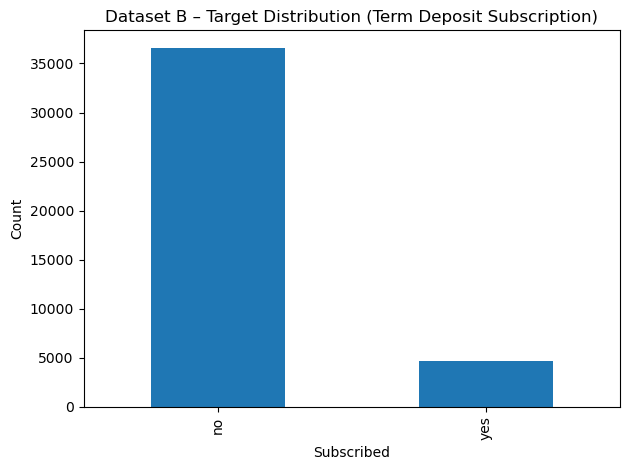

In [54]:
TARGET_B = "y"

print("Class distribution:")
print(dfB[TARGET_B].value_counts())

print("\nMissing values per column:")
print(dfB.isna().sum())

print("\nExact duplicate rows:", dfB.duplicated().sum())

ax = dfB[TARGET_B].value_counts().plot(kind="bar", title="Dataset B – Target Distribution (Term Deposit Subscription)")
ax.set_xlabel("Subscribed"); ax.set_ylabel("Count")
plt.tight_layout(); plt.savefig(OUT/"figures"/"B_class_distribution.png", dpi=150); plt.show()


## 2.2 Feature groups and locked train/test split

In [56]:
NUMERIC_B = ["age", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
CATEGORICAL_B = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "day_of_week", "poutcome"]
FEATURES_B = NUMERIC_B + CATEGORICAL_B
EXCLUDED_LEAKAGE_B = ["duration"]  # excluded: only known after the call, leaks the outcome

print("Numeric features:", NUMERIC_B)
print("Categorical features:", CATEGORICAL_B)
print("Excluded (leakage risk):", EXCLUDED_LEAKAGE_B)

usableB = dfB.dropna(subset=[TARGET_B]).copy()
train_B, test_B = train_test_split(
    usableB, test_size=0.20, random_state=SEED, stratify=usableB[TARGET_B]
)

X_train_B, y_train_B = train_B[FEATURES_B], train_B[TARGET_B]
X_test_B, y_test_B = test_B[FEATURES_B], test_B[TARGET_B]

print("Train shape:", X_train_B.shape, " Test shape:", X_test_B.shape)
print("Train class balance:\n", y_train_B.value_counts(normalize=True).round(3))


Numeric features: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Excluded (leakage risk): ['duration']
Train shape: (32950, 19)  Test shape: (8238, 19)
Train class balance:
 y
no     0.887
yes    0.113
Name: proportion, dtype: float64


## 2.3 Preprocessing pipelines and 5-fold Stratified CV (Dataset B)

In [58]:
bernoulli_prep_B, categoricalnb_prep_B, gaussian_prep_B = build_preprocessors(NUMERIC_B, CATEGORICAL_B)

core_pipelines_B = {
    "Dummy_most_frequent": Pipeline([("prep", bernoulli_prep_B), ("model", DummyClassifier(strategy="most_frequent"))]),
    "GaussianNB":          Pipeline([("prep", gaussian_prep_B),  ("model", GaussianNB())]),
    "BernoulliNB":         Pipeline([("prep", bernoulli_prep_B), ("model", BernoulliNB(alpha=1.0, binarize=0.0))]),
    "CategoricalNB":       Pipeline([("prep", categoricalnb_prep_B), ("model", CategoricalNB(alpha=1.0))]),
}

Xt_check_B = categoricalnb_prep_B.fit_transform(X_train_B)
assert np.nanmin(np.asarray(Xt_check_B)) >= 0, "CategoricalNB representation must be non-negative."
print("CategoricalNB representation verified non-negative. Min code:", np.nanmin(np.asarray(Xt_check_B)))


CategoricalNB representation verified non-negative. Min code: 0.0


,model,accuracy_mean,macro_f1_mean,macro_f1_sd,weighted_f1_mean,cv_time_seconds
0,CategoricalNB,0.841942,0.683532,0.003254,0.856985,2.276388
1,BernoulliNB,0.802731,0.651554,0.002820,0.829355,2.452429
2,GaussianNB,0.830865,0.649837,0.005611,0.844880,0.981321
3,Dummy_most_frequent,0.887344,0.470155,0.000023,0.834379,1.916582



Fold-level macro F1 per model:
  Dummy_most_frequent   : [0.4702, 0.4702, 0.4702, 0.4701, 0.4701]
  GaussianNB            : [0.6537, 0.653, 0.6499, 0.6401, 0.6524]
  BernoulliNB           : [0.6532, 0.6493, 0.6503, 0.6492, 0.6557]
  CategoricalNB         : [0.6868, 0.6808, 0.6795, 0.6863, 0.6843]


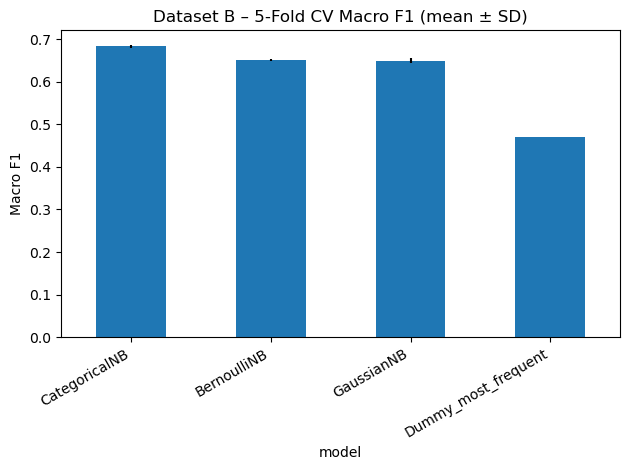

In [60]:
cv_B = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rows_B = []
fold_detail_B = {}
for name, pipe in core_pipelines_B.items():
    t0 = time.perf_counter()
    scores = cross_validate(pipe, X_train_B, y_train_B, cv=cv_B, scoring=scoring, n_jobs=1)
    elapsed = time.perf_counter() - t0
    fold_detail_B[name] = scores["test_macro_f1"].tolist()
    rows_B.append({
        "model": name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_sd": scores["test_macro_f1"].std(ddof=1),
        "weighted_f1_mean": scores["test_weighted_f1"].mean(),
        "cv_time_seconds": elapsed,
    })

cv_results_B = pd.DataFrame(rows_B).sort_values("macro_f1_mean", ascending=False).reset_index(drop=True)
cv_results_B.to_csv(OUT/"results"/"B_cv_results.csv", index=False)
display(cv_results_B)

print("\nFold-level macro F1 per model:")
for name, vals in fold_detail_B.items():
    print(f"  {name:22s}: {[round(v,4) for v in vals]}")

ax = cv_results_B.set_index("model")[["macro_f1_mean"]].plot(
    kind="bar", yerr=cv_results_B.set_index("model")["macro_f1_sd"],
    legend=False, title="Dataset B – 5-Fold CV Macro F1 (mean ± SD)"
)
ax.set_ylabel("Macro F1"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig(OUT/"figures"/"B_cv_comparison.png", dpi=150); plt.show()


In [64]:
nb_only_B = cv_results_B[cv_results_B["model"] != "Dummy_most_frequent"]
best_nb_name_B = nb_only_B.iloc[0]["model"]
print(f"Selected Naive Bayes model for Dataset B (by mean CV macro F1): {best_nb_name_B}")
print(nb_only_B.iloc[0])

best_nb_pipeline_B = core_pipelines_B[best_nb_name_B]
best_nb_pipeline_B.fit(X_train_B, y_train_B)


Selected Naive Bayes model for Dataset B (by mean CV macro F1): CategoricalNB
model               CategoricalNB
accuracy_mean            0.841942
macro_f1_mean            0.683532
macro_f1_sd              0.003254
weighted_f1_mean         0.856985
cv_time_seconds          2.276388
Name: 0, dtype: object


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('bins',
                                                                   KBinsDiscretizer(encode='ordinal'))]),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('safe_ordinal',
                                                                   SafeOrdinalToNonNegative())]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('model', CategoricalNB())])

## 2.4 Locked test-set evaluation (Dataset B)

=== CategoricalNB on the locked test set (Dataset B) ===
              precision    recall  f1-score   support

          no       0.95      0.88      0.91      7310
         yes       0.39      0.63      0.48       928

    accuracy                           0.85      8238
   macro avg       0.67      0.75      0.70      8238
weighted avg       0.89      0.85      0.86      8238

{'model': 'CategoricalNB', 'accuracy': 0.8489924739014324, 'macro_precision': 0.6712991083650539, 'macro_recall': 0.7530956648898532, 'macro_f1': 0.697896326105536, 'weighted_f1': 0.8634122229873435}


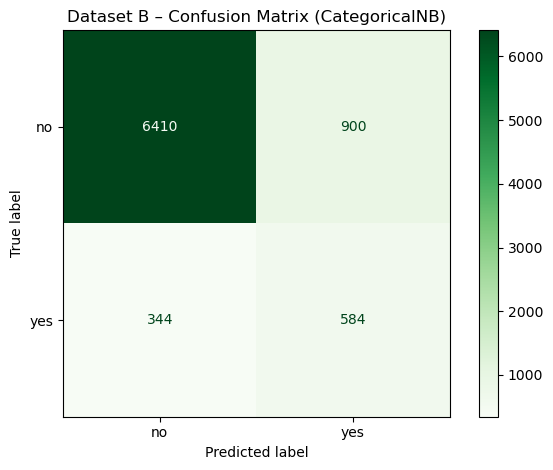

In [66]:
y_pred_B = best_nb_pipeline_B.predict(X_test_B)
probs_B = best_nb_pipeline_B.predict_proba(X_test_B)

print(f"=== {best_nb_name_B} on the locked test set (Dataset B) ===")
print(classification_report(y_test_B, y_pred_B, zero_division=0))

test_metrics_B = {
    "model": best_nb_name_B,
    "accuracy": accuracy_score(y_test_B, y_pred_B),
    "macro_precision": precision_score(y_test_B, y_pred_B, average="macro", zero_division=0),
    "macro_recall": recall_score(y_test_B, y_pred_B, average="macro", zero_division=0),
    "macro_f1": f1_score(y_test_B, y_pred_B, average="macro"),
    "weighted_f1": f1_score(y_test_B, y_pred_B, average="weighted"),
}
print(test_metrics_B)

ConfusionMatrixDisplay.from_predictions(y_test_B, y_pred_B, cmap="Greens", xticks_rotation=0)
plt.title(f"Dataset B – Confusion Matrix ({best_nb_name_B})")
plt.tight_layout(); plt.savefig(OUT/"figures"/"B_confusion_matrix.png", dpi=150); plt.show()


In [68]:
conf_B = probs_B.max(axis=1)
err_mask_B = (y_pred_B != y_test_B.values)

errors_B = test_B.loc[err_mask_B, FEATURES_B + [TARGET_B]].copy()
errors_B["Predicted"] = y_pred_B[err_mask_B]
errors_B["Confidence"] = conf_B[err_mask_B]
errors_B = errors_B.sort_values("Confidence", ascending=False)

print(f"Total errors: {err_mask_B.sum()} out of {len(y_test_B)} test cases")
display(errors_B.head(5))
errors_B.to_csv(OUT/"results"/"B_error_analysis.csv", index=False)


Total errors: 1244 out of 8238 test cases


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job,...,default,housing,loan,contact,month,day_of_week,poutcome,y,Predicted,Confidence
38977,23,2,6,2,-3.0,92.713,-33.0,0.718,5023.5,student,...,no,yes,no,cellular,dec,fri,success,no,yes,0.999990
37918,25,1,1,1,-3.4,92.379,-29.8,0.809,5017.5,admin.,...,no,yes,no,cellular,sep,thu,success,no,yes,0.999970
2257,39,4,999,0,1.1,93.994,-36.4,4.856,5191.0,blue-collar,...,unknown,no,no,telephone,may,tue,nonexistent,yes,no,0.999967
3685,37,3,999,0,1.1,93.994,-36.4,4.859,5191.0,blue-collar,...,unknown,no,no,telephone,may,fri,nonexistent,yes,no,0.999955
40836,30,4,19,1,-1.1,94.199,-37.5,0.879,4963.6,student,...,no,yes,no,cellular,sep,mon,success,no,yes,0.999952


## 2.5 New-customer prediction function (Dataset B)

In [70]:
def predict_term_deposit_response(customer_profile: dict) -> dict:
    """
    Predicts whether a client will subscribe to a term deposit.
    customer_profile must contain every key in FEATURES_B ('duration' is intentionally excluded).
    Returns predicted class, full posterior distribution, confidence, and a review flag.
    """
    missing = [c for c in FEATURES_B if c not in customer_profile]
    if missing:
        raise ValueError(f"Missing mandatory fields: {missing}")

    row = pd.DataFrame([customer_profile], columns=FEATURES_B)
    p = best_nb_pipeline_B.predict_proba(row)[0]
    classes = best_nb_pipeline_B.classes_

    distribution = {str(c): float(v) for c, v in zip(classes, p)}
    confidence = float(p.max())
    predicted = str(classes[int(np.argmax(p))])
    review = "high_confidence" if confidence >= 0.60 else ("moderate_confidence_review" if confidence >= 0.40 else "low_confidence_manual_review")

    return {
        "model_used": best_nb_name_B,
        "predicted_response": predicted,
        "posterior_distribution": distribution,
        "confidence": confidence,
        "review_recommendation": review,
    }


example_profile_B = X_test_B.iloc[0].to_dict()
print("Example input profile:", example_profile_B)
print()
print("Prediction:", predict_term_deposit_response(example_profile_B))


Example input profile: {'age': 32, 'campaign': 5, 'pdays': 999, 'previous': 0, 'emp.var.rate': 1.4, 'cons.price.idx': 93.918, 'cons.conf.idx': -42.7, 'euribor3m': 4.961, 'nr.employed': 5228.1, 'job': 'management', 'marital': 'divorced', 'education': 'university.degree', 'default': 'no', 'housing': 'no', 'loan': 'no', 'contact': 'cellular', 'month': 'jul', 'day_of_week': 'tue', 'poutcome': 'nonexistent'}

Prediction: {'model_used': 'CategoricalNB', 'predicted_response': 'no', 'posterior_distribution': {'no': 0.9973666832763672, 'yes': 0.002633316723631387}, 'confidence': 0.9973666832763672, 'review_recommendation': 'high_confidence'}


## 2.6 Save Dataset B artifacts

In [72]:
dump(best_nb_pipeline_B, OUT/"models"/f"B_{best_nb_name_B}_pipeline.joblib")

pred_out_B = test_B[FEATURES_B + [TARGET_B]].copy()
pred_out_B["predicted_response"] = y_pred_B
pred_out_B["max_posterior"] = conf_B
pred_out_B.to_csv(OUT/"results"/"B_test_predictions.csv", index=False)

print("Dataset B artifacts saved under:", OUT.resolve())
print(sorted(p.name for p in (OUT/"models").glob("B_*")))
print(sorted(p.name for p in (OUT/"results").glob("B_*")))


Dataset B artifacts saved under: C:\Users\izhar\pred 4\da4_outputs
['B_CategoricalNB_pipeline.joblib']
['B_cv_results.csv', 'B_error_analysis.csv', 'B_test_predictions.csv']


---
# Summary

| | Dataset A – Customer Segmentation | Dataset B – Bank Marketing |
|---|---|---|
| Target | `Segmentation` (A/B/C/D) | `y` (yes/no) |
| Models trained | Dummy, GaussianNB, BernoulliNB, CategoricalNB, TabTransformer | Dummy, GaussianNB, BernoulliNB, CategoricalNB |
| Selection | Best NB chosen by mean 5-fold CV macro F1, then compared with TabTransformer on the locked test set | Best NB chosen by mean 5-fold CV macro F1 |
| Artifacts | `da4_outputs/models`, `da4_outputs/results`, `da4_outputs/figures` | same folders, `B_*` prefix |

All reported numbers come directly from running the cells above on the uploaded ZIP datasets — nothing here is fabricated or estimated.